# Road Damage Dataset EDA

Quick exploratory analysis of the files in `data/` and the available annotations.

In [8]:
from pathlib import Path
import json
from collections import Counter, defaultdict

DATA_DIR = Path("..") / "data"
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "labels"
YOLO_LABELS_DIR = DATA_DIR / "labels-YOLO"
COCO_JSON = DATA_DIR / "annotations_coco.json"

In [2]:
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
image_files = [p for p in IMAGES_DIR.rglob("*") if p.suffix.lower() in image_exts] if IMAGES_DIR.exists() else []
label_files = list(LABELS_DIR.glob("*.txt")) if LABELS_DIR.exists() else []
yolo_label_files = list(YOLO_LABELS_DIR.glob("*.txt")) if YOLO_LABELS_DIR.exists() else []

print("images:", len(image_files))
print("labels:", len(label_files))
print("labels-YOLO:", len(yolo_label_files))

image_stems = {p.stem for p in image_files}
label_stems = {p.stem for p in label_files}

missing_labels = image_stems - label_stems
missing_images = label_stems - image_stems

print("images without labels:", len(missing_labels))
print("labels without images:", len(missing_images))

if missing_labels:
    print("sample missing labels:", sorted(list(missing_labels))[:5])
if missing_images:
    print("sample missing images:", sorted(list(missing_images))[:5])

images: 2009
labels: 2009
labels-YOLO: 2009
images without labels: 0
labels without images: 0


In [3]:
coco = None
if COCO_JSON.exists():
    with COCO_JSON.open("r", encoding="utf-8") as f:
        coco = json.load(f)
    print("coco loaded")
    print("images:", len(coco.get("images", [])))
    print("annotations:", len(coco.get("annotations", [])))
    print("categories:", len(coco.get("categories", [])))
else:
    print("COCO JSON not found at", COCO_JSON)

coco loaded
images: 2009
annotations: 4737
categories: 3


In [4]:
if coco:
    categories = coco.get("categories", [])
    annotations = coco.get("annotations", [])
    images = coco.get("images", [])

    cat_id_to_name = {c["id"]: c.get("name", str(c["id"])) for c in categories}
    cat_counts = Counter([ann["category_id"] for ann in annotations])

    rows = [
        {"category_id": k, "category": cat_id_to_name.get(k, str(k)), "count": v}
        for k, v in cat_counts.most_common()
    ]
    try:
        import pandas as pd
        df = pd.DataFrame(rows)
        display(df)
    except Exception:
        for row in rows[:20]:
            print(row)

    ann_per_image = Counter([ann["image_id"] for ann in annotations])
    counts = list(ann_per_image.values())
    if counts:
        avg = sum(counts) / len(counts)
        print("annotations per image: min", min(counts), "max", max(counts), "avg", round(avg, 2))
    else:
        print("no annotations found")

,category_id,category,count
0,1,crack,2519
1,0,pothole,1261
2,2,manhole,957


annotations per image: min 1 max 13 avg 2.36


In [5]:
def parse_yolo_labels(paths):
    counts = Counter()
    total_boxes = 0
    for path in paths:
        try:
            text = path.read_text(encoding="utf-8").strip()
        except Exception:
            continue
        if not text:
            continue
        for line in text.splitlines():
            parts = line.split()
            if not parts:
                continue
            try:
                cls = int(float(parts[0]))
            except Exception:
                continue
            counts[cls] += 1
            total_boxes += 1
    return counts, total_boxes

if label_files:
    yolo_counts, yolo_total = parse_yolo_labels(label_files)
    print("labels parsed:", len(label_files))
    print("total boxes:", yolo_total)
    for cls_id, count in yolo_counts.most_common(10):
        print("class", cls_id, "count", count)
else:
    print("no label files found in", LABELS_DIR)

if yolo_label_files:
    yolo2_counts, yolo2_total = parse_yolo_labels(yolo_label_files)
    print("labels-YOLO parsed:", len(yolo_label_files))
    print("total boxes:", yolo2_total)
    for cls_id, count in yolo2_counts.most_common(10):
        print("class", cls_id, "count", count)

labels parsed: 2009
total boxes: 4737
class 1 count 2519
class 0 count 1261
class 2 count 957
labels-YOLO parsed: 2009
total boxes: 4737
class 1 count 2519
class 0 count 1261
class 2 count 957


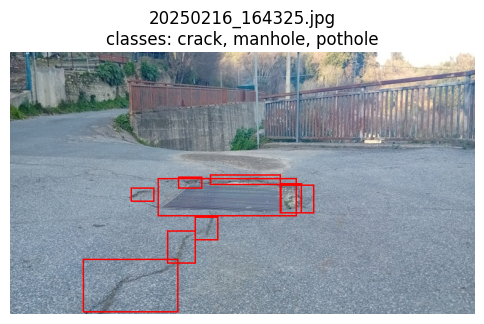

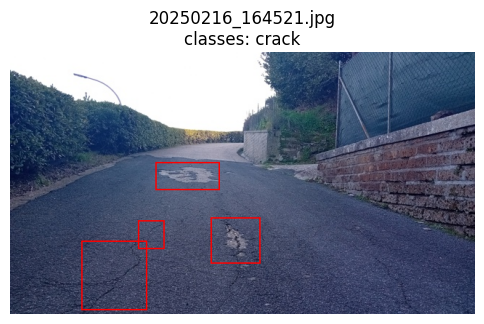

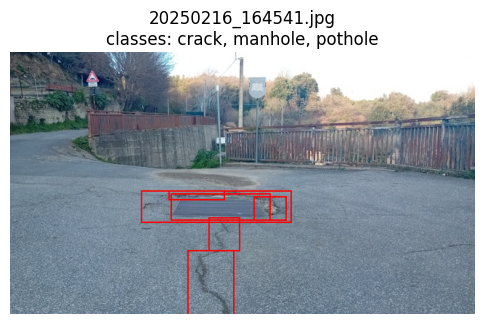

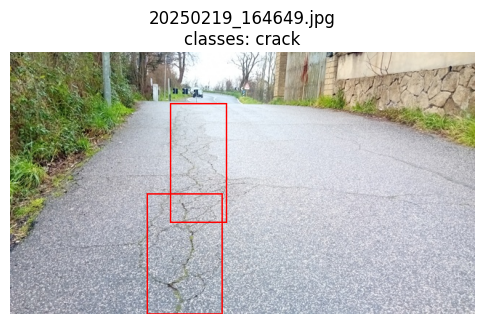

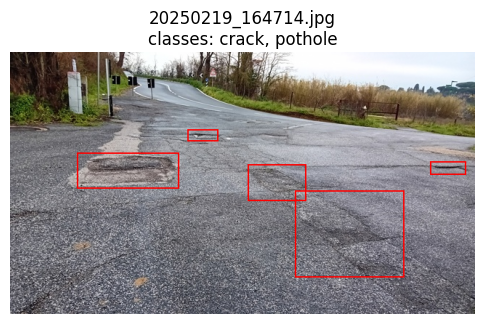

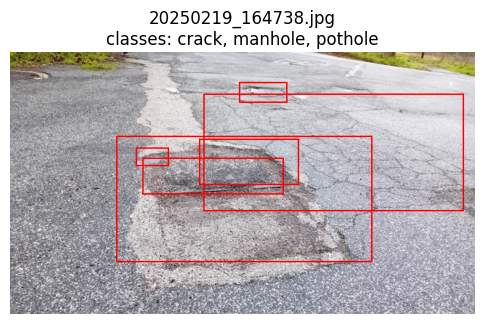

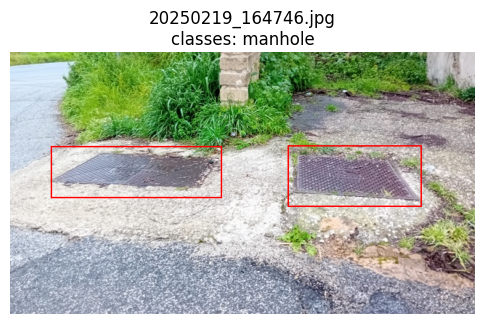

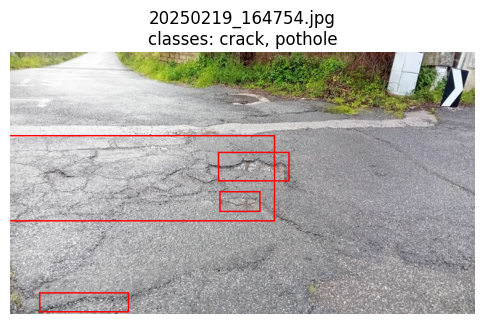

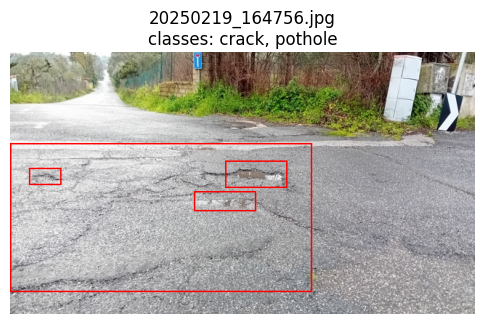

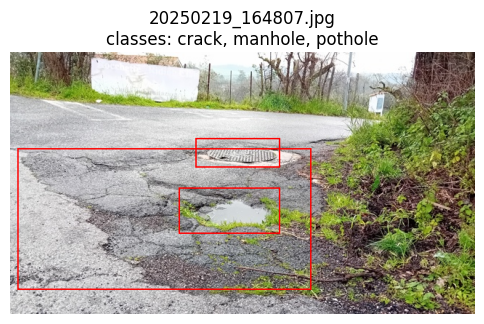

In [7]:
def load_image(path):
    from PIL import Image
    return Image.open(path).convert("RGB")

def draw_coco_boxes(image, anns, color="red"):
    from PIL import ImageDraw
    draw = ImageDraw.Draw(image)
    for ann in anns:
        bbox = ann.get("bbox", [])
        if len(bbox) != 4:
            continue
        x, y, w, h = bbox
        draw.rectangle([x, y, x + w, y + h], outline=color, width=2)
    return image

try:
    import matplotlib.pyplot as plt
    from PIL import Image, ImageDraw
except Exception as exc:
    print("Install Pillow and matplotlib to visualize images:", exc)
else:
    if coco:
        categories = coco.get("categories", [])
        images = coco.get("images", [])
        annotations = coco.get("annotations", [])
        cat_id_to_name = {c["id"]: c.get("name", str(c["id"])) for c in categories}
        image_id_to_info = {img["id"]: img for img in images}
        anns_by_image = defaultdict(list)
        for ann in annotations:
            anns_by_image[ann["image_id"]].append(ann)

        image_ids = [img_id for img_id in image_id_to_info if img_id in anns_by_image][:10]
        if not image_ids:
            print("no annotated images to display")
        else:
            for image_id in image_ids:
                info = image_id_to_info[image_id]
                file_name = info.get("file_name", "")
                img_path = IMAGES_DIR / file_name
                if not img_path.exists():
                    img_path = DATA_DIR / file_name
                if not img_path.exists():
                    print("missing:", file_name)
                    continue
                image = load_image(img_path)
                image = draw_coco_boxes(image, anns_by_image[image_id])
                class_names = sorted({
                    cat_id_to_name.get(ann.get("category_id"), str(ann.get("category_id")))
                    for ann in anns_by_image[image_id]
                })
                if not class_names:
                    class_names = ["unknown"]
                title = f"{file_name}\nclasses: {', '.join(class_names)}"
                plt.figure(figsize=(6, 6))
                plt.imshow(image)
                plt.title(title)
                plt.axis("off")
                plt.show()
    else:
        print("COCO annotations not loaded")